In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import importlib
import json
import sys

sys.path.append("/kaggle/input/models/leonidtikhanov/pinn-model/pytorch/default/4")

import pinn_model
pinn_model = importlib.reload(pinn_model)

print(pinn_model.__file__)
print("run_experiment:", hasattr(pinn_model, "run_experiment"))

/kaggle/input/models/leonidtikhanov/pinn-model/pytorch/default/4/pinn_model.py
run_experiment: True


In [2]:
print("torch version:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

if torch.cuda.is_available():
    device = "cuda"
    print("gpu:", torch.cuda.get_device_name(0))
else:
    device = "cpu"

work_dir = Path("/kaggle/working")
if not work_dir.exists():
    work_dir = Path(".")

print("device:", device)
print("work_dir:", work_dir)

torch version: 2.10.0+cu128
cuda available: True
gpu: Tesla T4
device: cuda
work_dir: /kaggle/working


In [3]:
m_values = [5, 10, 20, 30, 40]
dtype_values = ["fp32", "fp64"]
seed_values = [0, 1]


base_config = {
    "task_name": "helmholtz1d",
    "dtype": "fp32",
    "seed": 0,
    "device": device,
    "m": 20,
    "lambda_val": 1.0,
    "hid_size": 128,
    "num_layers": 4,
    "n_collocation": 5000,
    "n_bc": 2,
    "adam_steps": 2000,
    "lbfgs_steps": 1000,
    "lr_adam": 1e-3,
    "use_adam": True,
    "use_lbfgs": True,
    "lbfgs_tolerance_grad": 1e-12,
    "lbfgs_tolerance_change": 1e-14,
    "lbfgs_history_size": 100,
    "log_dir": str(work_dir / "runs" / "helmholtz_tmp"),
}

len(m_values) * len(dtype_values) * len(seed_values)

20

In [4]:
all_summaries = []
all_histories = {}

for m in m_values:
    for dtype in dtype_values:
        for seed in seed_values:
            config = base_config.copy()
            config["m"] = m
            config["dtype"] = dtype
            config["seed"] = seed
            config["log_dir"] = str(work_dir / "runs" / f"helmholtz_m{m}_{dtype}_{seed}")

            run_dir = Path(config["log_dir"])
            summary_file = run_dir / "summary.json"
            metrics_file = run_dir / "metrics.csv"

            if summary_file.exists() and metrics_file.exists():
                with open(summary_file) as f:
                    summary = json.load(f)
                history = pd.read_csv(metrics_file)
            else:
                history, summary = pinn_model.run_experiment(config)

            best = history.loc[history["l2_error"].idxmin()]
            summary["m"] = m
            summary["lambda_val"] = config["lambda_val"]
            summary["best_l2_error"] = float(best["l2_error"])
            summary["best_step"] = int(best["step"])
            summary["l2_ratio"] = float(summary["final_l2_error"] / summary["best_l2_error"])
            all_summaries.append(summary)
            all_histories[f"m{m}_{dtype}_{seed}"] = history

            print(m, dtype, seed, summary["final_l2_error"], summary["best_l2_error"], summary["time_sec"])

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


5 fp32 0 0.0003950501268263906 0.00012559370952658355 47.601051330566406
5 fp32 1 0.00014235764683689922 3.904392724507488e-05 41.149386405944824
5 fp64 0 0.00017337655486814195 7.867530385551748e-05 117.95188903808594
5 fp64 1 0.00016846094910539545 4.0099485495170586e-05 120.20382475852966
10 fp32 0 0.010082083754241467 0.010082083754241467 41.62517762184143
10 fp32 1 0.09661135822534561 0.09661135822534561 41.17559552192688
10 fp64 0 0.04254105203767902 0.04254105203767902 119.56415271759033
10 fp64 1 0.0063527287590072895 0.0063527287590072895 120.34825491905212
20 fp32 0 278184.8125 1.0298686027526855 41.34163498878479
20 fp32 1 nan 1.020623803138733 40.92470908164978
20 fp64 0 15.684476890075592 1.0012795470249394 118.88424873352051
20 fp64 1 1.0159500932460188 1.0159500932460188 119.10318112373352
30 fp32 0 21.71476173400879 1.1183208227157593 28.47717809677124
30 fp32 1 19.138944625854492 1.0000180006027222 40.97812294960022
30 fp64 0 23178.202383053915 1.0323122255157855 119.3

In [5]:
df = pd.DataFrame(all_summaries)
df = df.sort_values(["m", "dtype", "seed"]).reset_index(drop=True)

df.to_csv(work_dir / "helmholtz_results_summary.csv", index=False)

cols = ["m", "lambda_val", "dtype", "seed", "final_l2_error", "best_l2_error", "l2_ratio", "best_step", "final_loss", "time_sec", "log_dir"]
df[cols]

,m,lambda_val,dtype,seed,final_l2_error,best_l2_error,l2_ratio,best_step,final_loss,time_sec,log_dir
0,5,1.0,fp32,0,0.000395,0.000126,3.145461,2900,1.864671e-04,47.601051,/kaggle/working/runs/helmholtz_m5_fp32_0
1,5,1.0,fp32,1,0.000142,0.000039,3.646089,2800,9.746380e-05,41.149386,/kaggle/working/runs/helmholtz_m5_fp32_1
2,5,1.0,fp64,0,0.000173,0.000079,2.203697,2900,4.736568e-04,117.951889,/kaggle/working/runs/helmholtz_m5_fp64_0
3,5,1.0,fp64,1,0.000168,0.000040,4.201075,2900,2.757805e-04,120.203825,/kaggle/working/runs/helmholtz_m5_fp64_1
4,10,1.0,fp32,0,0.010082,0.010082,1.000000,3000,5.939511e-01,41.625178,/kaggle/working/runs/helmholtz_m10_fp32_0
5,10,1.0,fp32,1,0.096611,0.096611,1.000000,3000,6.758261e-01,41.175596,/kaggle/working/runs/helmholtz_m10_fp32_1
6,10,1.0,fp64,0,0.042541,0.042541,1.000000,3000,1.975597e-01,119.564153,/kaggle/working/runs/helmholtz_m10_fp64_0
7,10,1.0,fp64,1,0.006353,0.006353,1.000000,3000,7.227903e-02,120.348255,/kaggle/working/runs/helmholtz_m10_fp64_1
8,20,1.0,fp32,0,278184.812500,1.029869,270116.801072,1,1.159679e+11,41.341635,/kaggle/working/runs/helmholtz_m20_fp32_0
9,20,1.0,fp32,1,NaN,1.020624,NaN,1,NaN,40.924709,/kaggle/working/runs/helmholtz_m20_fp32_1


In [6]:
grouped = df.groupby(["m", "dtype"])[["final_l2_error", "best_l2_error", "l2_ratio", "final_loss", "time_sec"]].agg(["mean", "std"])
grouped.to_csv(work_dir / "helmholtz_results_grouped.csv")
grouped

final_l2_error               best_l2_error                 l2_ratio  \
                   mean           std          mean       std           mean   
m  dtype                                                                       
5  fp32        0.000269      0.000179      0.000082  0.000061       3.395775   
   fp64        0.000171      0.000003      0.000059  0.000027       3.202386   
10 fp32        0.053347      0.061185      0.053347  0.061185       1.000000   
   fp64        0.024447      0.025589      0.024447  0.025589       1.000000   
20 fp32   278184.812500           NaN      1.025246  0.006537  270116.801072   
   fp64        8.350213     10.372215      1.008615  0.010374       8.332217   
30 fp32       20.426853      1.821378      1.059169  0.083653      19.277946   
   fp64    11599.479406  16374.787069      1.063676  0.044355   11235.830225   
40 fp32       33.459137     45.904152      1.001586  0.002243      33.354924   
   fp64       22.089862     29.825569      1.001687  0.002386      22.017269   

                          final_loss                  time_sec            
                   std          mean           std        mean       std  
m  dtype                                                                  
5  fp32       0.353998  1.419654e-04  6.293481e-05   44.375219  4.562016  
   fp64       1.412359  3.747187e-04  1.399197e-04  119.077857  1.592359  
10 fp32       0.000000  6.348886e-01  5.789439e-02   41.400387  0.317903  
   fp64       0.000000  1.349194e-01  8.858680e-02  119.956204  0.554444  
20 fp32            NaN  1.159679e+11           NaN   41.133172  0.294811  
   fp64      10.369320  7.770976e+06  8.602677e+04  118.993715  0.154809  
30 fp32       0.197065  3.915736e+07  3.478965e+03   34.727651  8.839503  
   fp64   15863.057141  4.419994e+08  5.690865e+08  113.343559  8.506135  
40 fp32      45.756772  1.243282e+08  9.321987e+05   37.044705  5.311976  
   fp64      29.722908  1.250905e+08  8.567846e+05  114.727159  5.950765

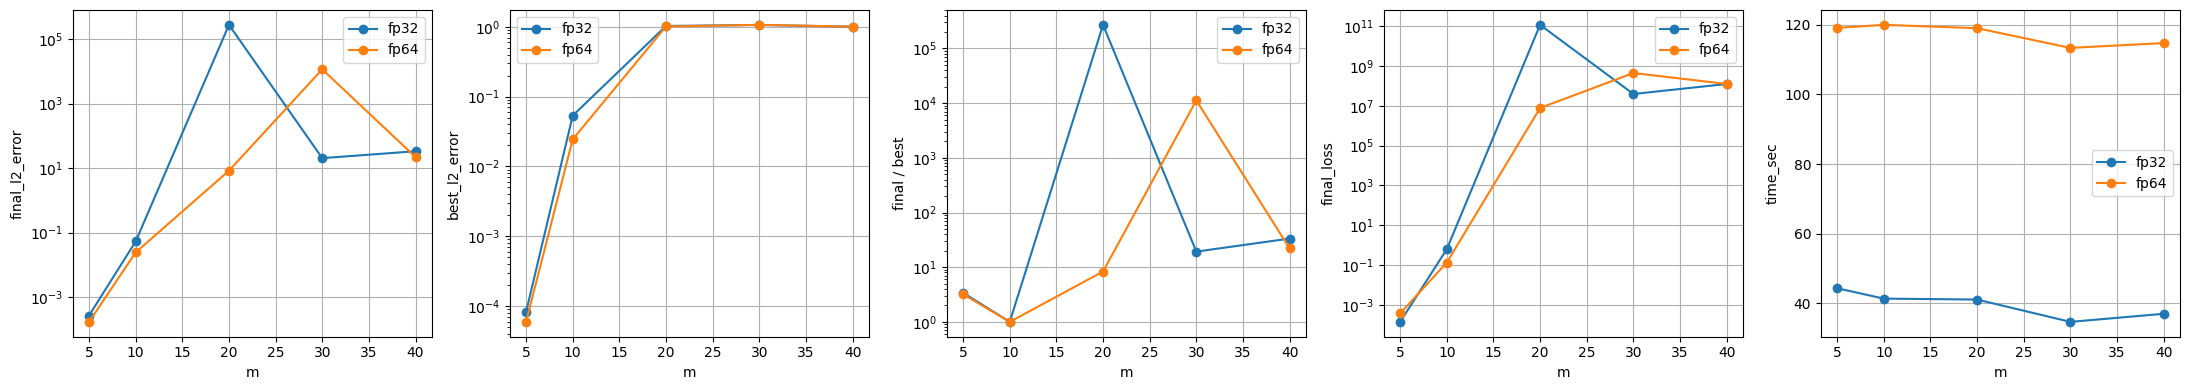

In [7]:
mean_df = df.groupby(["m", "dtype"])[["final_l2_error", "best_l2_error", "l2_ratio", "final_loss", "time_sec"]].mean().reset_index()

fig, ax = plt.subplots(1, 5, figsize=(22, 4))

for dtype in dtype_values:
    part = mean_df[mean_df["dtype"] == dtype].sort_values("m")
    ax[0].plot(part["m"], part["final_l2_error"], "o-", label=dtype)
    ax[1].plot(part["m"], part["best_l2_error"], "o-", label=dtype)
    ax[2].plot(part["m"], part["l2_ratio"], "o-", label=dtype)
    ax[3].plot(part["m"], part["final_loss"], "o-", label=dtype)
    ax[4].plot(part["m"], part["time_sec"], "o-", label=dtype)

for a in ax:
    a.grid(True)
    a.set_xlabel("m")
    a.legend()

ax[0].set_yscale("log")
ax[1].set_yscale("log")
ax[2].set_yscale("log")
ax[3].set_yscale("log")
ax[0].set_ylabel("final_l2_error")
ax[1].set_ylabel("best_l2_error")
ax[2].set_ylabel("final / best")
ax[3].set_ylabel("final_loss")
ax[4].set_ylabel("time_sec")

fig.tight_layout()
plt.show()

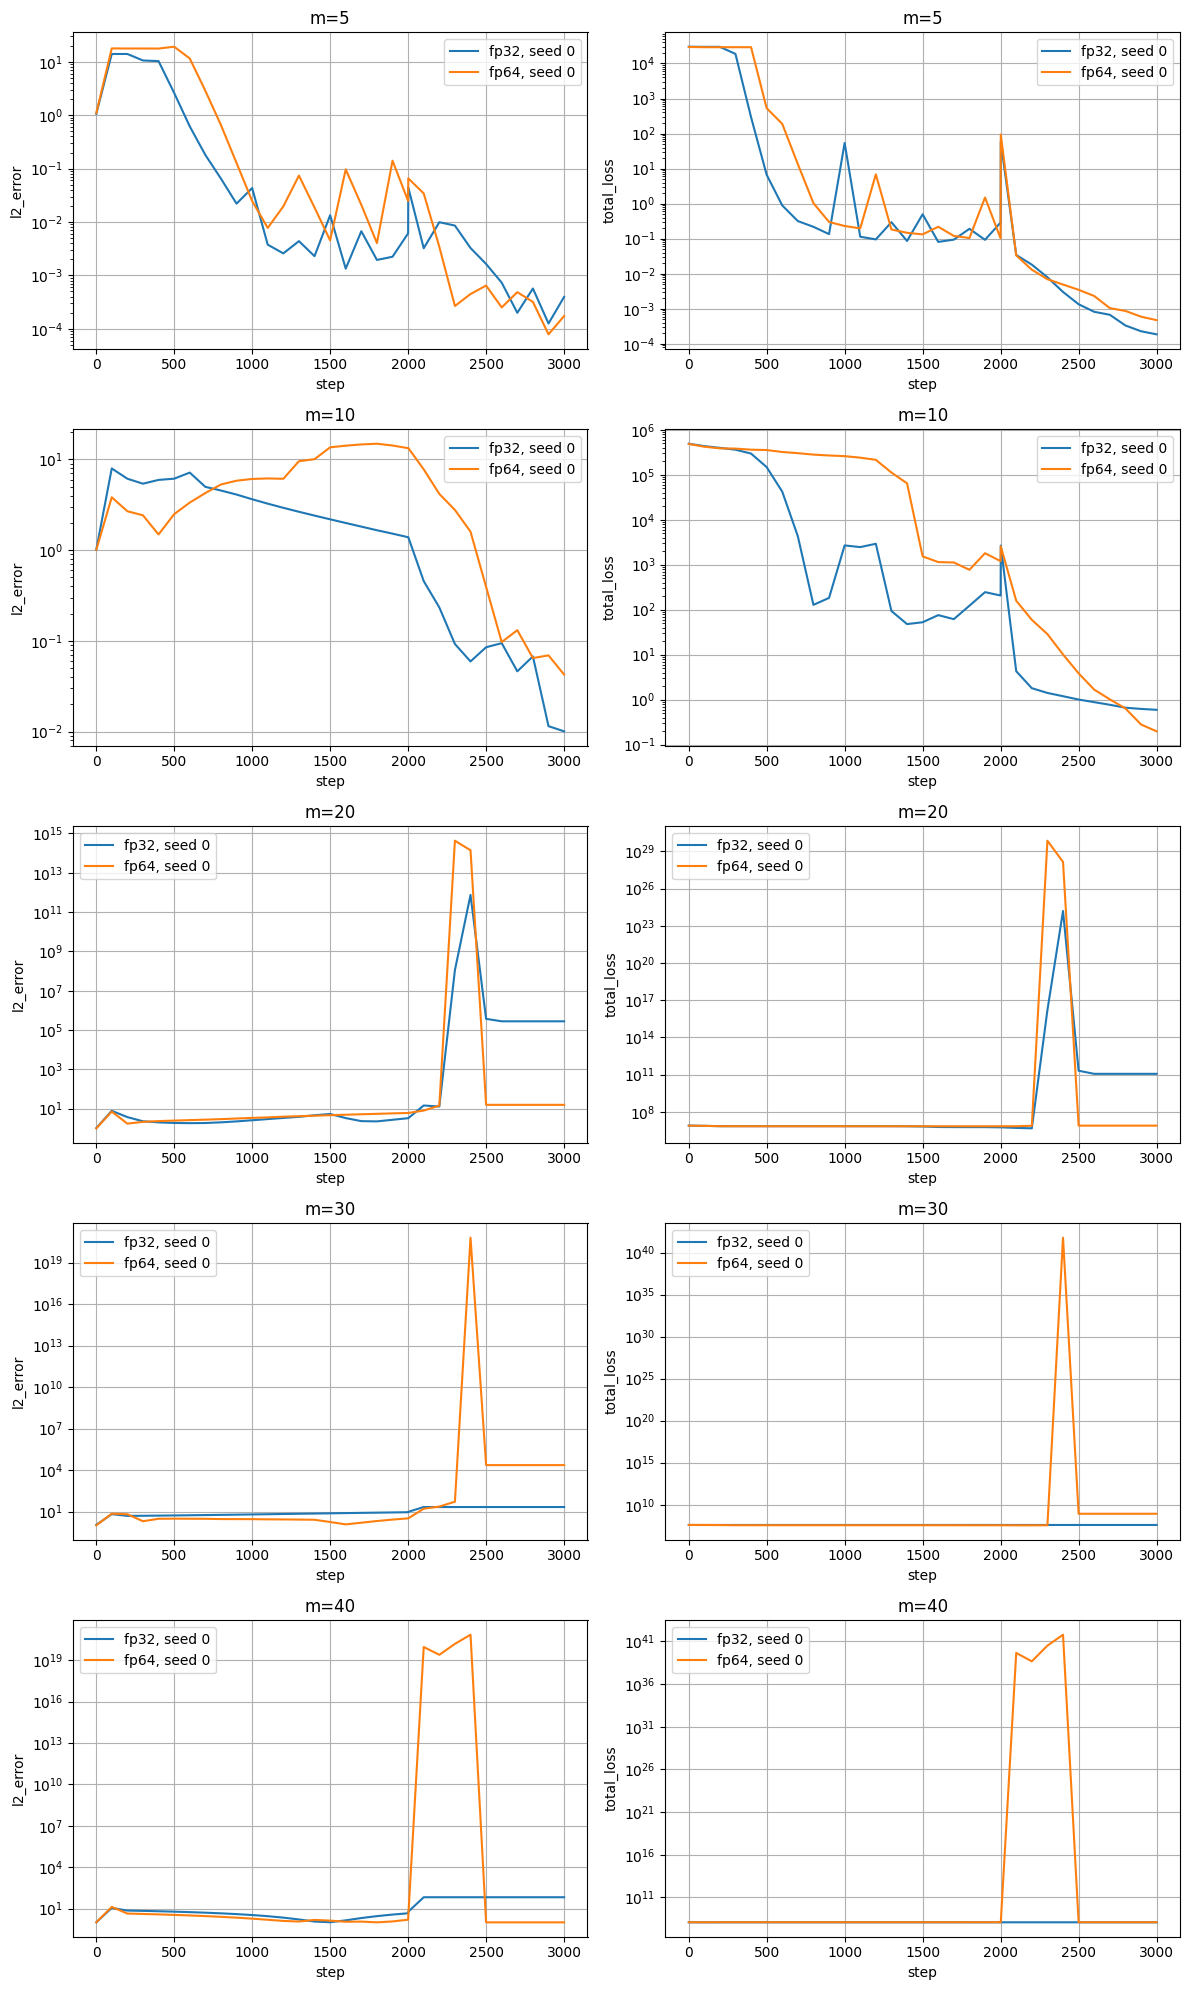

In [8]:
fig, ax = plt.subplots(len(m_values), 2, figsize=(12, 4 * len(m_values)))
ax = np.array(ax).reshape(len(m_values), 2)

for i, m in enumerate(m_values):
    for dtype in dtype_values:
        seed = seed_values[0]
        p = work_dir / "runs" / f"helmholtz_m{m}_{dtype}_{seed}" / "metrics.csv"
        if p.exists():
            h = pd.read_csv(p)
            label = f"{dtype}, seed {seed}"
            ax[i, 0].plot(h["step"], h["l2_error"], label=label)
            ax[i, 1].plot(h["step"], h["total_loss"], label=label)

    ax[i, 0].set_title(f"m={m}")
    ax[i, 1].set_title(f"m={m}")
    ax[i, 0].set_yscale("log")
    ax[i, 1].set_yscale("log")
    ax[i, 0].set_xlabel("step")
    ax[i, 1].set_xlabel("step")
    ax[i, 0].set_ylabel("l2_error")
    ax[i, 1].set_ylabel("total_loss")
    ax[i, 0].grid(True)
    ax[i, 1].grid(True)
    ax[i, 0].legend()
    ax[i, 1].legend()

fig.tight_layout()
plt.show()

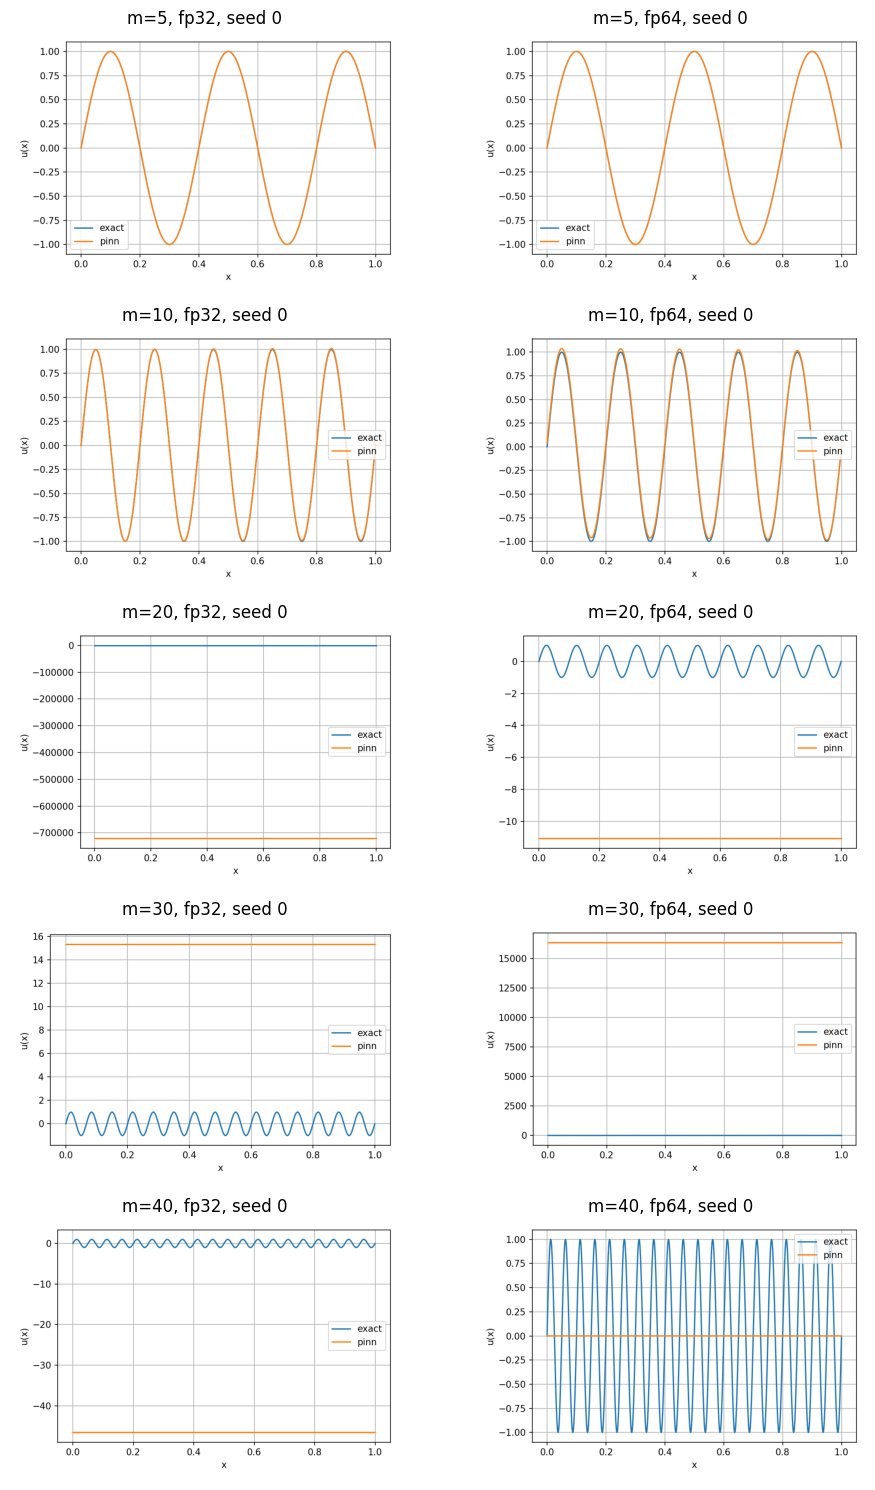

In [9]:
fig, ax = plt.subplots(len(m_values), len(dtype_values), figsize=(5 * len(dtype_values), 3 * len(m_values)))
ax = np.array(ax).reshape(len(m_values), len(dtype_values))

for i, m in enumerate(m_values):
    for j, dtype in enumerate(dtype_values):
        seed = seed_values[0]
        p = work_dir / "runs" / f"helmholtz_m{m}_{dtype}_{seed}" / "solution_t1.png"
        ax[i, j].set_title(f"m={m}, {dtype}, seed {seed}")
        ax[i, j].axis("off")
        if p.exists():
            img = plt.imread(p)
            ax[i, j].imshow(img)

fig.tight_layout()
plt.show()